In [ ]:
import warnings
warnings.filterwarnings("ignore")
!python cnn_gru_svm_main.py \
  --operation train \
  --train_dataset ./prepared_data/X_train.npy \
  --train_labels ./prepared_data/y_train.npy \
  --validation_dataset ./prepared_data/X_val.npy \
  --validation_labels ./prepared_data/y_val.npy \
  --checkpoint_path ./checkpoints \
  --log_path ./logs \
  --model_name emotion_cnn_gru_svm \
  --result_path ./results_cnn

2025-04-30 04:30:36.349387: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745987436.372953   38721 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745987436.380935   38721 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745987436.399671   38721 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745987436.399700   38721 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745987436.399707   38721 computation_placer.cc:177] computation placer alr

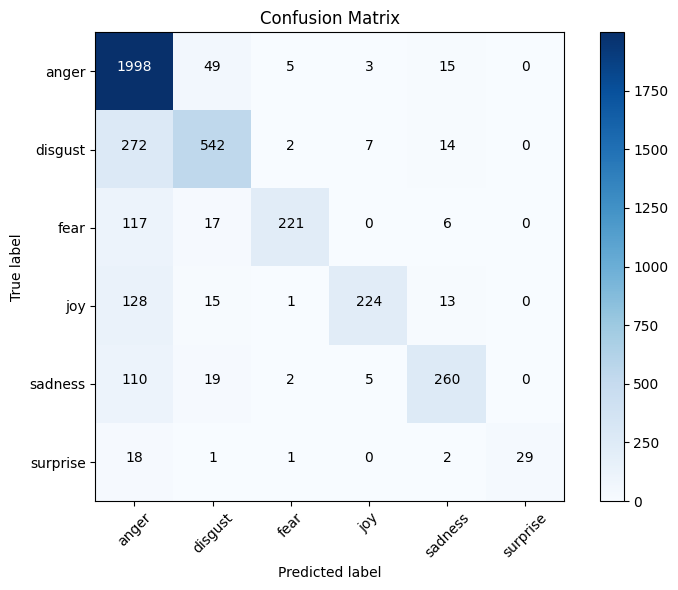

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import confusion_matrix
class_names = ["anger","disgust","fear","joy","sadness","surprise"]
result_path ="results_cnn/"
file_path = os.path.join(result_path, "preds_acts.txt")

preds = []
acts = []

with open(file_path, "r") as f:
    next(f)  # Sauter l'en-tête "Prediction\tActual"
    for line in f:
        pred_str, act_str = line.strip().split('\t')
        
        # Nettoyage : enlever [ ] puis splitter sur les espaces
        pred_values = np.array(pred_str.strip('[]').split(), dtype=float)
        act_values = np.array(act_str.strip('[]').split(), dtype=float)
        
        preds.append(np.argmax(pred_values))
        acts.append(np.argmax(act_values))

preds = np.array(preds)
acts = np.array(acts)

# Calcul de la matrice de confusion
conf = confusion_matrix(acts, preds)

# Affichage
plt.figure(figsize=(8, 6))
plt.imshow(conf, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)
plt.ylabel('True label')
plt.xlabel('Predicted label')

# Annoter les cases avec les valeurs
thresh = conf.max() / 2.0
for i in range(conf.shape[0]):
    for j in range(conf.shape[1]):
        plt.text(j, i, format(conf[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if conf[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

In [8]:
from sklearn.metrics import confusion_matrix, classification_report
# --- Precision, Recall, F1-Score ---
report = classification_report(acts, preds, target_names=class_names, digits=4)
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

       anger     0.7560    0.9652    0.8479      2070
     disgust     0.8429    0.6476    0.7324       837
        fear     0.9526    0.6122    0.7454       361
         joy     0.9372    0.5879    0.7226       381
     sadness     0.8387    0.6566    0.7365       396
    surprise     1.0000    0.5686    0.7250        51

    accuracy                         0.7993      4096
   macro avg     0.8879    0.6730    0.7516      4096
weighted avg     0.8190    0.7993    0.7913      4096

